In [2]:
# Import necessary libraries for data analysis and visualization

import pandas as pd    # For data manipulation and analysis (DataFrame operations)
import numpy as np      # For numerical computations
import seaborn as sns       # For statistical data visualization (built on matplotlib)
import matplotlib.pyplot as plt      # For creating plots and visualizations

# Import specific tools for better date handling in plots
from matplotlib.dates import MonthLocator, DateFormatter

In [3]:
# Load the supermarket sales dataset into a pandas DataFrame
df = pd.read_csv("supermarket_sales.csv")
# df now contains the complete supermarket sales transaction data

In [4]:
# Display the first 5 rows to get an overview of the data structure
df.head()

,Invoice ID,Branch,City,Customer type,Gender,Product line,Unit price,Quantity,Tax 5%,Total,Date,Time,Payment,cogs,gross margin percentage,gross income,Rating
0,750-67-8428,A,Yangon,Member,Female,Health and beauty,74.69,7,26.1415,548.9715,1/5/2019,13:08,Ewallet,522.83,4.761905,26.1415,9.1
1,226-31-3081,C,Naypyitaw,Normal,Female,Electronic accessories,15.28,5,3.8200,80.2200,3/8/2019,10:29,Cash,76.40,4.761905,3.8200,9.6
2,631-41-3108,A,Yangon,Normal,Male,Home and lifestyle,46.33,7,16.2155,340.5255,3/3/2019,13:23,Credit card,324.31,4.761905,16.2155,7.4
3,123-19-1176,A,Yangon,Member,Male,Health and beauty,58.22,8,23.2880,489.0480,1/27/2019,20:33,Ewallet,465.76,4.761905,23.2880,8.4
4,373-73-7910,A,Yangon,Normal,Male,Sports and travel,86.31,7,30.2085,634.3785,2/8/2019,10:37,Ewallet,604.17,4.761905,30.2085,5.3


In [5]:
# Check the dimensions of the dataset
# Check the shape (number of rows and columns) to understand the size of our dataset
print(df.shape)

(1000, 17)


In [6]:
# Inspect data types, non-null counts, and memory usage
# Display detailed information about the dataset including data types, missing values, and memory consumption to identify data quality issues early
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 17 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Invoice ID               1000 non-null   object 
 1   Branch                   1000 non-null   object 
 2   City                     1000 non-null   object 
 3   Customer type            1000 non-null   object 
 4   Gender                   1000 non-null   object 
 5   Product line             1000 non-null   object 
 6   Unit price               1000 non-null   float64
 7   Quantity                 1000 non-null   int64  
 8   Tax 5%                   1000 non-null   float64
 9   Total                    1000 non-null   float64
 10  Date                     1000 non-null   object 
 11  Time                     1000 non-null   object 
 12  Payment                  1000 non-null   object 
 13  cogs                     1000 non-null   float64
 14  gross margin percentage  

In [7]:
# Generate summary statistics for numerical columns
# Generate descriptive statistics (count, mean, std, min, max, quartiles) for all numerical columns to understand the distribution and range of the data
df.describe()

,Unit price,Quantity,Tax 5%,Total,cogs,gross margin percentage,gross income,Rating
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.00000,1000.000000,1000.000000,1000.00000
mean,55.672130,5.510000,15.379369,322.966749,307.58738,4.761905,15.379369,6.97270
std,26.494628,2.923431,11.708825,245.885335,234.17651,0.000000,11.708825,1.71858
min,10.080000,1.000000,0.508500,10.678500,10.17000,4.761905,0.508500,4.00000
25%,32.875000,3.000000,5.924875,124.422375,118.49750,4.761905,5.924875,5.50000
50%,55.230000,5.000000,12.088000,253.848000,241.76000,4.761905,12.088000,7.00000
75%,77.935000,8.000000,22.445250,471.350250,448.90500,4.761905,22.445250,8.50000
max,99.960000,10.000000,49.650000,1042.650000,993.00000,4.761905,49.650000,10.00000


In [8]:
# Convert 'Date' column to proper datetime format
# Convert 'Date' column from object (string) to datetime data type.
# This fixes the data type mismatch and enables time-based analysis and visualizations (e.g., sales trends over days/months).
df['Date'] = pd.to_datetime(df['Date'])

In [23]:
# Convert 'Time' column to proper datetime format
# Convert 'Time' column from object (string) to datetime data type.
# This resolves the data type mismatch observed in df.info() and prepares the column for temporal operations and plotting.
df['Time'] = pd.to_datetime(df['Time'])

In [10]:
# Quick verification
df[['Date', 'Time']].dtypes

Date    datetime64[ns]
Time    datetime64[ns]
dtype: object

In [11]:
# Check unique values in the 'gross margin percentage' column
# Examine the unique values in 'gross margin percentage' to verify if the column contains only a single constant value (as observed during exploration). This helps us spot redundant columns early in the analysis.
df['gross margin percentage'].unique()

array([4.76190476])

In [12]:
# Drop the 'gross margin percentage' column
# Remove the 'gross margin percentage' column because it contains only one repeated value and does not provide any useful information for analysis.
df.drop(columns=['gross margin percentage'], inplace=True)

In [13]:
# To confirm the 'gross margin percentage' has been dropped
df.shape

(1000, 16)

In [14]:
# Check for missing values in the dataset
# Count the number of missing values in each column to identify any data quality issues before proceeding with further analysis.
df.isnull().sum()
# No missing values in the supermarket sales transaction data

Invoice ID       0
Branch           0
City             0
Customer type    0
Gender           0
Product line     0
Unit price       0
Quantity         0
Tax 5%           0
Total            0
Date             0
Time             0
Payment          0
cogs             0
gross income     0
Rating           0
dtype: int64

In [15]:
# Check for duplicate rows in the dataset

# Count the number of duplicate rows to ensure data quality and avoid biased results in our analysis.
df.duplicated().sum()
# No duplicated record in the supermarket sales transaction data

0

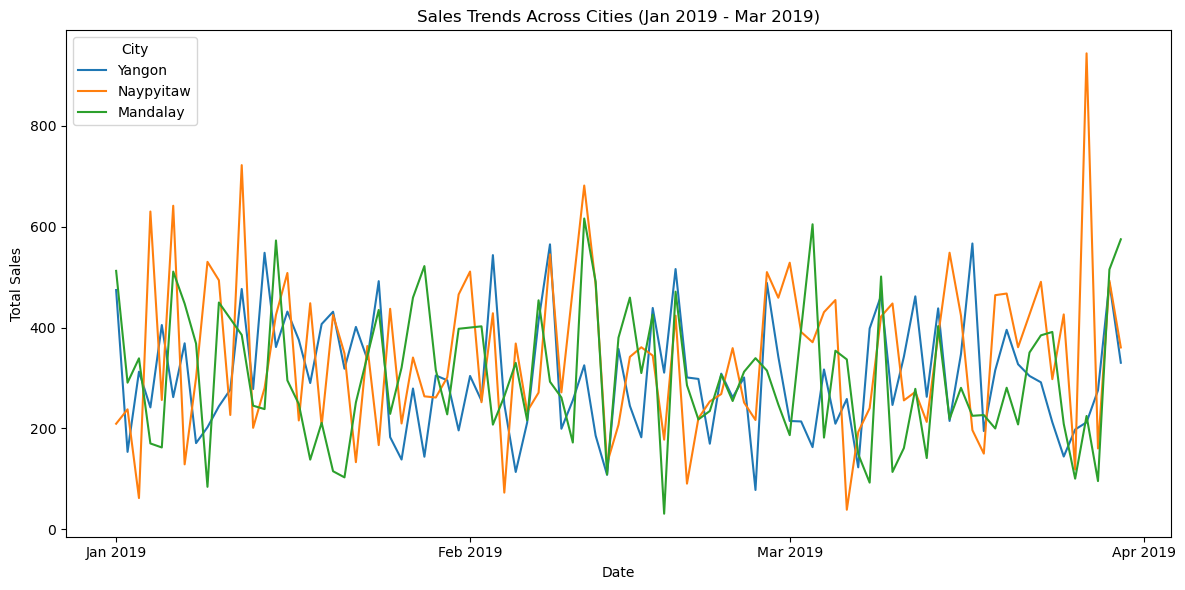

In [16]:
# Line plot - Sales trends across cities over time

# Create a line plot to visualize the daily sales trends ('Total') across different cities
# This helps us compare how sales performance changes over time in Yangon, Naypyitaw, and Mandalay.
plt.figure(figsize=(12, 6))
sns.lineplot(data=df, x='Date', y='Total', hue='City', errorbar=None)

# Format the x-axis to show one tick per month for better readability
plt.gca().xaxis.set_major_locator(MonthLocator())
plt.gca().xaxis.set_major_formatter(DateFormatter('%b %Y'))  # Format: Apr 2019

plt.title('Sales Trends Across Cities (Jan 2019 - Mar 2019)')
plt.xlabel('Date')
plt.ylabel('Total Sales')
plt.legend(title='City')
plt.tight_layout()
plt.show()
# Insight: Sales show clear weekly fluctuations in all cities, with Naypyitaw consistently generating the highest revenue, while Yangon and Mandalay display more similar but lower patterns.

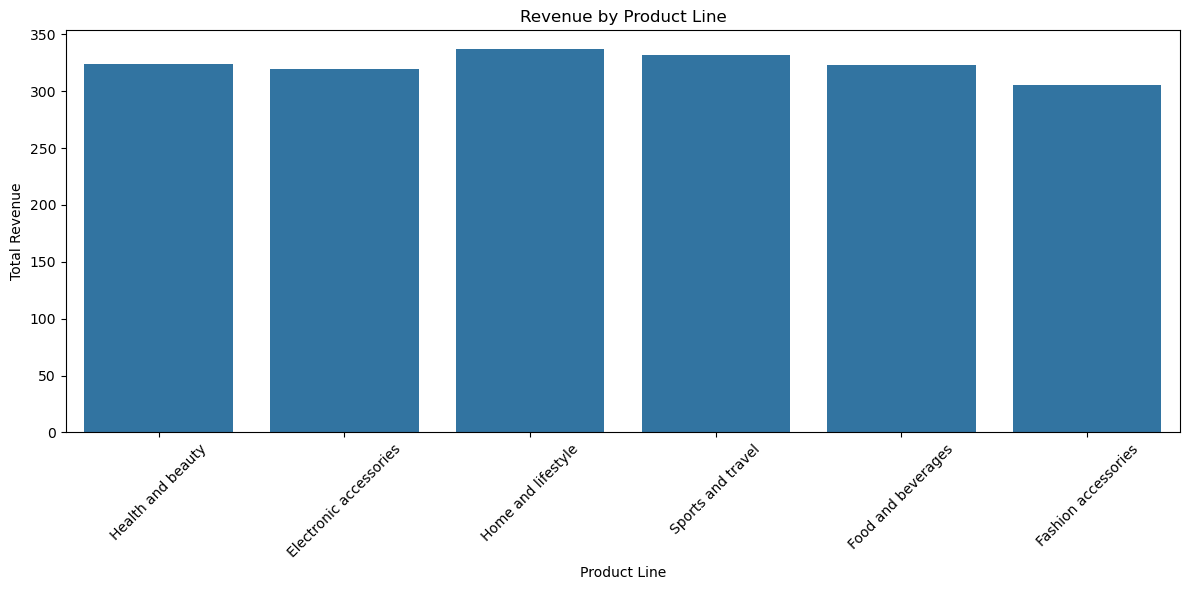

In [17]:
# Bar chart - Revenue by Product Line
# Create a bar plot to compare total revenue generated by each product line.
# This helps answer the question: "Which product line generates the most revenue?"
plt.figure(figsize=(12, 6))
sns.barplot(data=df, x='Product line', y='Total', errorbar=None)

plt.title('Revenue by Product Line')
plt.xlabel('Product Line')
plt.ylabel('Total Revenue')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Insight: Home and lifestyle generates the highest revenue among all product lines, followed closely by Sports and travel, while Fashion accessories contributes the least.

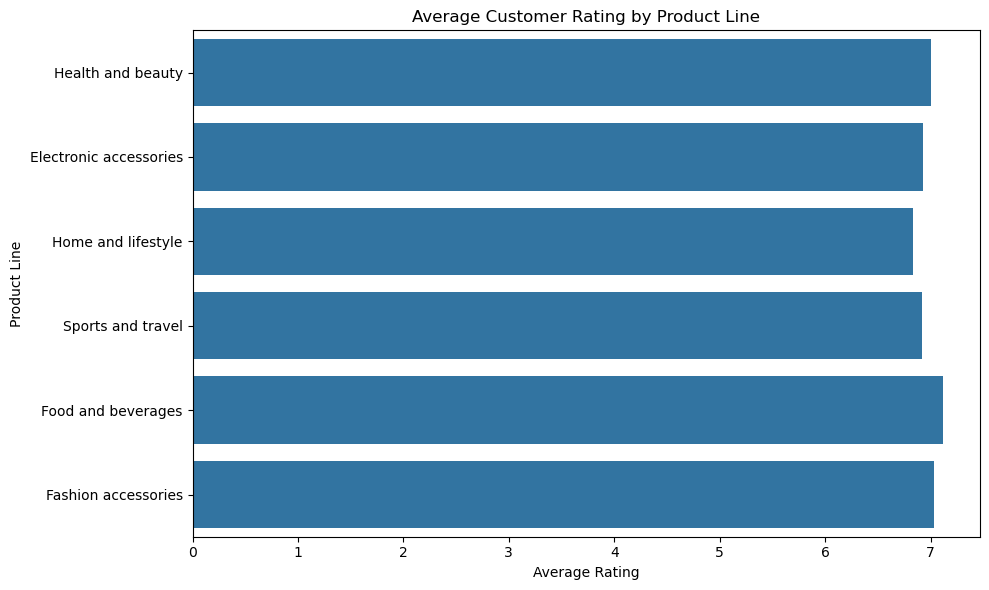

In [18]:
# Column chart - Average Customer Rating by Product Line

# Create a horizontal bar plot to compare average customer ratings across product lines.
# This answers the question: "Which product line has the highest customer rating?"
plt.figure(figsize=(10, 6))
sns.barplot(data=df, x='Rating', y='Product line', errorbar=None)

plt.title('Average Customer Rating by Product Line')
plt.xlabel('Average Rating')
plt.ylabel('Product Line')
plt.tight_layout()
plt.show()

# Insight: Food and beverages receives the highest average customer rating, indicating strong customer satisfaction in this category.

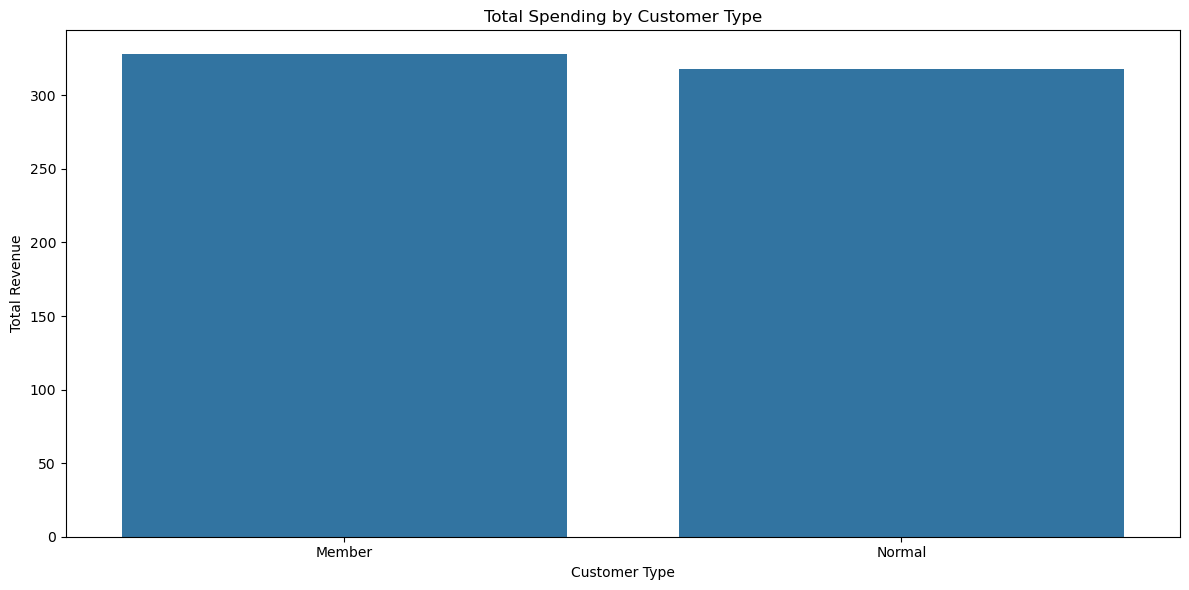

In [19]:
# Bar chart - Total Spending by Customer Type

# Create a bar plot to compare total revenue between Member and Normal customers.
# This answers the question: "Do members spend more than normal customers?"
plt.figure(figsize=(12, 6))
sns.barplot(data=df, x='Customer type', y='Total', errorbar=None)

plt.title('Total Spending by Customer Type')
plt.xlabel('Customer Type')
plt.ylabel('Total Revenue')
plt.tight_layout()
plt.show()

# Insight: Members spend slightly more than Normal customers, but the difference in total revenue between the two groups is very small.

Median of Total: 253.848
Original DataFrame shape: (1000, 16)
Filtered DataFrame shape (Total > median): (500, 16)
Median value used for filtering: 253.848


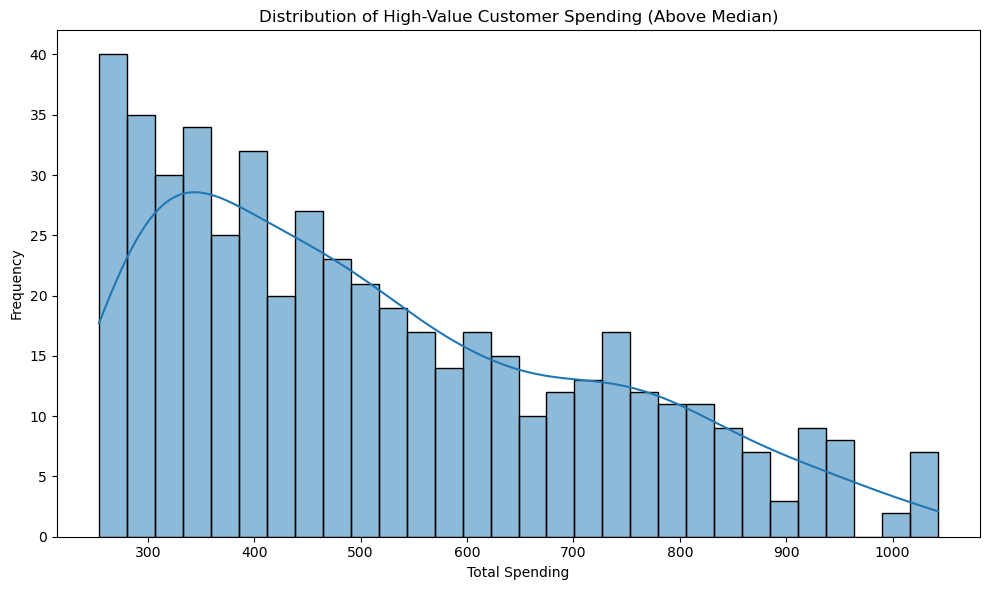

In [20]:
# Calculate median of Total and create high-value customer spending histogram

# Calculate the median of the Total column and store it in a variable
median_total = df['Total'].median()

# Print the median value for reference
print("Median of Total:", median_total)

# Filter transactions above the median (High-value purchases)
df_above_median = df[df['Total'] > median_total]

# Print summary to verify the filtering
print("Original DataFrame shape:", df.shape)
print("Filtered DataFrame shape (Total > median):", df_above_median.shape)
print("Median value used for filtering:", median_total)

# Create histogram of high-value customer spending
plt.figure(figsize=(10, 6))
sns.histplot(data=df_above_median, x='Total', bins=30, kde=True)

plt.title('Distribution of High-Value Customer Spending (Above Median)')
plt.xlabel('Total Spending')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()
# Insight: The number of high-value customers reduces as the transaction value increases.

Total Sales by Month (Highest to Lowest):
      Month       Total
1   January  116291.868
2     March  109455.507
0  February   97219.374


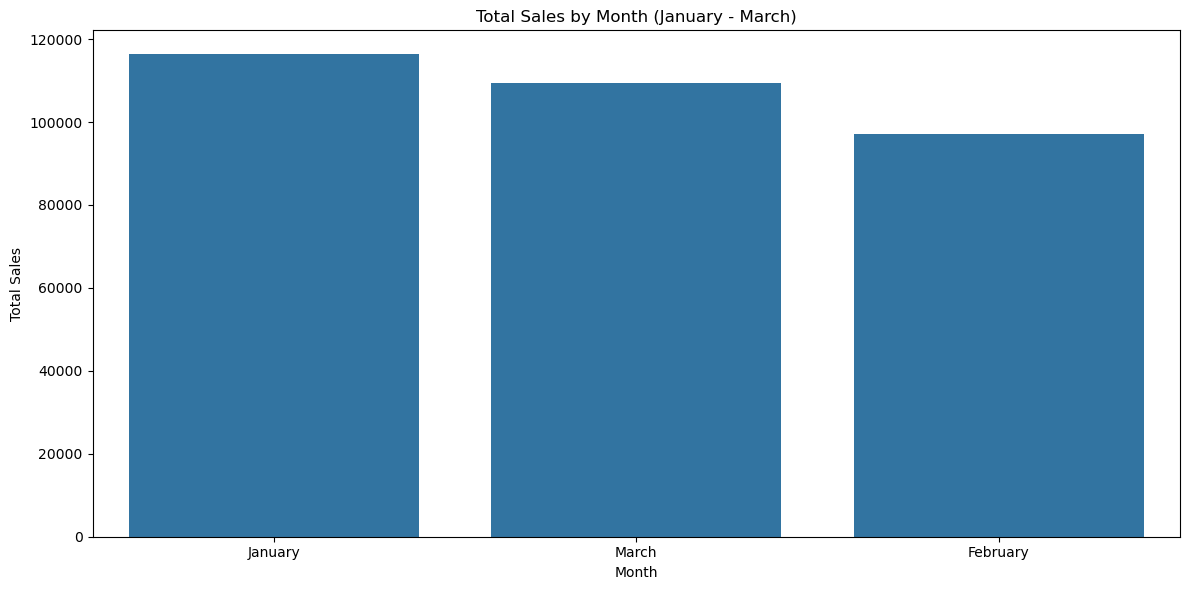

In [24]:
# 1. Extract Month name
# We use .dt.month_name() to convert the Date column into January, February, etc.
df['Month'] = df['Date'].dt.month_name()

# 2. Calculate total sales per month and sort from highest to lowest
# This identifies which specific months in the period generated the most revenue
monthly_sales = df.groupby('Month')['Total'].sum().reset_index()
monthly_sales = monthly_sales.sort_values(by='Total', ascending=False)

# 3. Display the numbers
print("Total Sales by Month (Highest to Lowest):")
print(monthly_sales)

# 4. Column Chart - Months with Most Sales
plt.figure(figsize=(12, 6))

sns.barplot(
    data=monthly_sales, 
    x='Month', 
    y='Total',
    errorbar=None            # removes black lines
)

plt.title('Total Sales by Month (January - March)')
plt.xlabel('Month')
plt.ylabel('Total Sales')
plt.tight_layout()
plt.show()

# Insight: January had the most sales, followed by March, and February had the least. 
# The dataset covers only three months, and while the differences are visible, the margin between them is not significant.

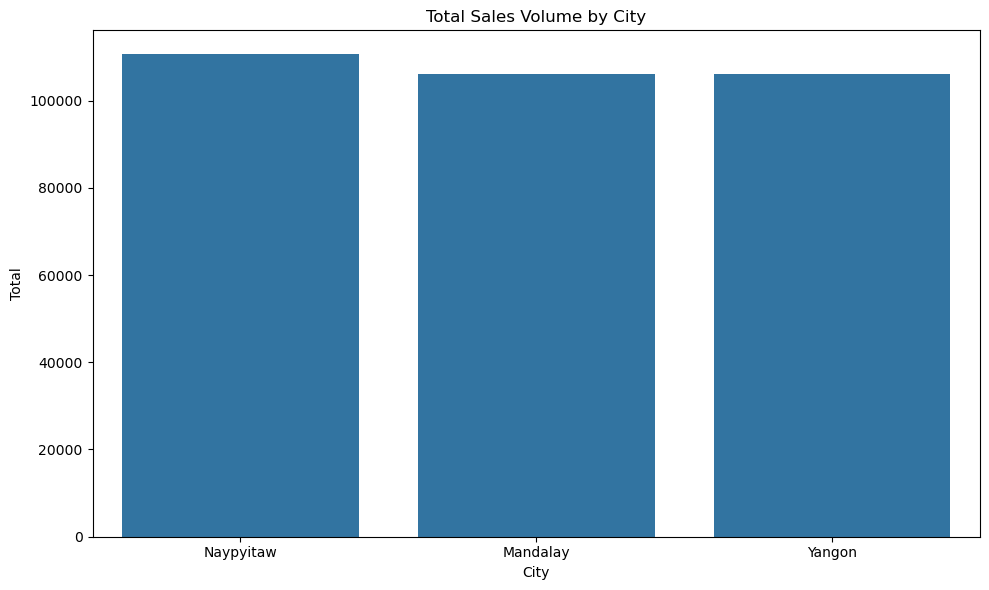

In [25]:
# 1. Column Chart - City with Highest Sales Volume
plt.figure(figsize=(10, 6))

# Using barplot to visualize the Total sales for each City
sns.barplot(
    data=df, 
    x='City', 
    y='Total', 
    errorbar=None    # removes black lines (uncertainty intervals)
)

plt.title('Total Sales Volume by City')
plt.xlabel('City')
plt.ylabel('Total Sales')
plt.tight_layout()
plt.show()

# Insight: Naypyitaw has the highest sales, second to Mandalay, and Yangon has the least, with no significant margin differences between the three cities